# Ocean Carbon Sampling
## A map-first visual story of fixed-budget observing strategies

<div style="padding:16px 18px;border-left:5px solid #0F766E;background:#F0FDFA;">
<b>Question</b><br>Under a fixed annual observation budget, does changing <i>where</i> we sample redistribute global monthly reconstruction risk?
</div>

**Demo status:** scientific content is source-grounded; layout remains open for portfolio refinement.

### Visual inheritance and redesign

This demo inherits the strongest visual language of the earlier course project: Pacific-centred Robinson maps, dark land, oceanographic colour maps, shared horizontal colour bars, and spatial comparisons before summary statistics. It replaces oversized canvases, repeated legends, and significance-first panels with a compact sequence: **observing geometry → hidden-set error geography → paired-seed evidence**.

In [1]:
from pathlib import Path

import pandas as pd

from ocean_carbon_sampling.demo_visuals import (
    plot_error_atlas,
    plot_sampling_atlas,
    plot_spatial_holdout_gate,
    plot_tradeoff_summary,
)

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
RESULTS = ROOT / 'results' / 'public'
fields = pd.read_parquet(RESULTS / 'osse_visual_demo_fields.parquet')
sampling = pd.read_parquet(RESULTS / 'osse_visual_demo_sampling.parquet')
metadata = pd.read_csv(RESULTS / 'osse_visual_demo_metadata.csv')
effects = pd.read_csv(RESULTS / 'osse_cross_year_paired_summary.csv')
regrid = pd.read_csv(RESULTS / 'osse_regrid_audit_paired_summary.csv')
spatial_blocks = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_blocks.csv')
spatial_summary = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_paired_summary.csv')
month_balance = pd.read_csv(RESULTS / 'osse_month_balance_strategy_summary.csv')
print('Curated visual-demo data loaded.')

Curated visual-demo data loaded.


In [2]:
metadata.rename(columns={
    'complete_month_cells': 'complete month-grid cells',
    'evaluation_month_cells': 'hidden evaluation rows',
    'map_grid_cells': 'mapped spatial cells',
})

,year,seed,budget,complete month-grid cells,candidate_month_cells,hidden evaluation rows,mapped spatial cells,sampling_longitude_degrees,sampling_latitude_degrees,map_role
0,2005,0,5000,487488,390000,97488,40624,10.0,5.0,representative spatial pattern; not inferentia...


## 0 · What is being predicted—and why monthly?

This project evaluates **reconstruction under a fixed annual observing budget**, not future-time forecasting. Each record is a month–location observation, but all 12 months are fitted jointly in one model. Cyclic month features preserve the seasonal cycle and keep December adjacent to January.

The random hidden set is stratified by month so every season has the same evaluation fraction; otherwise seasonal test composition could be mistaken for a sampling-strategy effect. In the stricter spatial holdout, all 12 months from one location stay in the same fold, preventing the model from training on another month at the evaluation location. A chronological split would instead test forecasting under temporal distribution shift—a valid but different question.

In [3]:
month_balance.query('budget == 5000').assign(
    strategy=lambda frame: frame['strategy'].replace({
        'random': 'Random',
        'spatial_coverage': 'Seasonally balanced spatial coverage',
        'historical_density': 'Historical spatiotemporal pattern',
    }),
    mean_abs_equal_deviation_pp=lambda frame: frame['mean_abs_equal_deviation_pp'].round(3),
    mean_max_abs_equal_deviation_pp=lambda frame: frame['mean_max_abs_equal_deviation_pp'].round(3),
)[['strategy', 'n_year_fold_seed_selections', 'minimum_months_covered',
   'mean_abs_equal_deviation_pp', 'mean_max_abs_equal_deviation_pp']]

,strategy,n_year_fold_seed_selections,minimum_months_covered,mean_abs_equal_deviation_pp,mean_max_abs_equal_deviation_pp
3,Historical spatiotemporal pattern,300,12,0.875,2.506
4,Random,300,12,0.292,0.754
5,Seasonally balanced spatial coverage,300,12,0.222,0.532


**Audit result.** Every one of the 1,800 selections covers all 12 months. At budget 5,000, the mean absolute deviation from an equal monthly share is only 0.292 percentage points for random and 0.222 for coverage. Their comparison therefore primarily changes spatial placement. Historical density deviates by 0.875 percentage points and is interpreted as a realistic historical **spatiotemporal** observing-pattern baseline, not a pure spatial control.

## 1 · Same budget, different observing geometry

Each strategy selects exactly 5,000 month-grid observations from the same candidate pool. Random and seasonally balanced spatial coverage have closely matched monthly allocation, so this map isolates their main difference: where observations are placed. Colour encodes the number selected within each 5° × 10° spatial block; no observations are discarded for plotting.

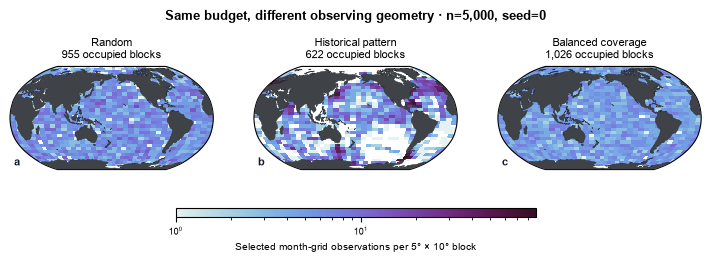

In [4]:
sampling_figure = plot_sampling_atlas(sampling, budget=5000, seed=0)

<div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:10px;margin:10px 0 22px 0;">
<div style="padding:10px;background:#F9FAFB;border-radius:6px;"><b>Random</b><br>Broad but uneven by chance.</div>
<div style="padding:10px;background:#FFF7ED;border-radius:6px;"><b>Historical pattern</b><br>Reproduces seasonal and spatial observation density.</div>
<div style="padding:10px;background:#F0FDFA;border-radius:6px;"><b>Balanced spatial coverage</b><br>Cycles across month × under-filled spatial blocks.</div>
</div>

## 2 · Where does coverage change error?

The maps below use every row of the locked 2005 hidden evaluation set. The hero panel shows the change in mean absolute error: blue cells favour spatial coverage; red cells favour random sampling. Values beyond the 98th percentile are colour-clipped only to protect contrast; they remain in all calculations.

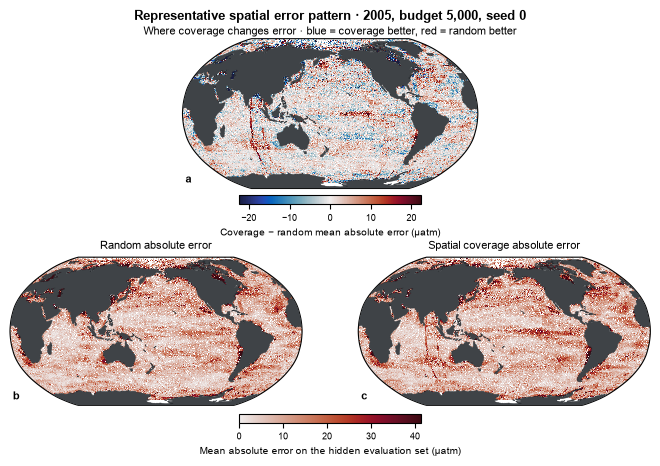

In [5]:
error_figure = plot_error_atlas(fields)

**Reading boundary.** This representative map uses 2005, seed 0 and budget 5,000 to localise the effect. It is not an inferential replicate and is not used alone to support the final claim.

## 3 · Does the pattern repeat?

Yes, but as a tradeoff. The figure below uses all 20 paired sampling seeds in each of three prespecified years. Points are paired-seed mean differences and intervals are 10,000-resample seed-bootstrap 95% intervals. Grid cells are not treated as independent replicates.

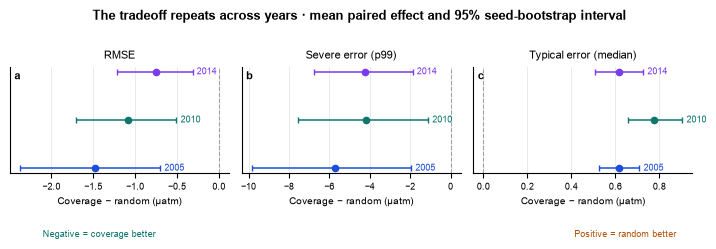

In [6]:
key_effects = effects.query(
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
).copy()
tradeoff_figure = plot_tradeoff_summary(key_effects)

In [7]:
key_effects.assign(
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    seed_bootstrap_low=lambda frame: frame['seed_bootstrap_low'].round(3),
    seed_bootstrap_high=lambda frame: frame['seed_bootstrap_high'].round(3),
)[[
    'year', 'metric', 'n_seeds', 'mean_difference',
    'seed_bootstrap_low', 'seed_bootstrap_high',
]].sort_values(['metric', 'year'])

,year,metric,n_seeds,mean_difference,seed_bootstrap_low,seed_bootstrap_high
36,2005,median_absolute_error,20,0.618,0.525,0.709
116,2010,median_absolute_error,20,0.777,0.655,0.904
196,2014,median_absolute_error,20,0.616,0.509,0.726
38,2005,p99_absolute_error,20,-5.701,-9.844,-1.952
118,2010,p99_absolute_error,20,-4.207,-7.562,-1.113
198,2014,p99_absolute_error,20,-4.253,-6.767,-1.877
39,2005,rmse,20,-1.484,-2.376,-0.701
119,2010,rmse,20,-1.088,-1.705,-0.507
199,2014,rmse,20,-0.749,-1.213,-0.315


## 4 · Robustness to spatial weighting

Replacing equal weighting within one-degree bins with native-cell-area weighting preserves all 12 prespecified direction checks: coverage still lowers RMSE and p99 error, raises median error, and historical-density allocation remains worse than random on RMSE.

In [8]:
audit_filter = (
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
)
equal_bin = key_effects.assign(method='equal-bin baseline')
area_weighted = regrid.query(audit_filter).assign(method='native-cell-area audit')
robustness = pd.concat([equal_bin, area_weighted], ignore_index=True)
robustness.pivot_table(
    index=['year', 'metric'], columns='method', values='mean_difference'
).round(3)

method                      equal-bin baseline  native-cell-area audit
year metric                                                           
2005 median_absolute_error               0.618                   0.637
     p99_absolute_error                 -5.701                  -5.693
     rmse                               -1.484                  -1.464
2010 median_absolute_error               0.777                   0.747
     p99_absolute_error                 -4.207                  -5.025
     rmse                               -1.088                  -1.153
2014 median_absolute_error               0.616                   0.594
     p99_absolute_error                 -4.253                  -4.264
     rmse                               -0.749                  -0.692

## 5 · Stricter validation: whole regions unseen

### What is a Global spatial-block holdout OSSE?

An **OSSE** (Observing System Simulation Experiment) treats a complete climate-model field as known truth, simulates where observations would be collected, reconstructs the unsampled ocean, and scores that reconstruction against the truth. A **spatial-block holdout** makes the test harder: instead of hiding scattered cells, it withholds whole geographic blocks. The model therefore cannot learn from another month at the same location or from a randomly hidden neighbour inside the held-out block.

Here, all 12 months of each 20° × 10° block stay together. Five checkerboard folds exhaust the occupied ocean blocks: one fold is evaluated while the other four provide candidates, repeated until every block has been held out once. The confirmatory comparison repeats this design in the prespecified years 2005, 2010 and 2014, using the same model, equal budgets, 20 paired sampling seeds per year–fold, and seed-bootstrap intervals. There is no extra buffer around held-out blocks, so this is a coarse unseen-region gate rather than a long-range extrapolation test.

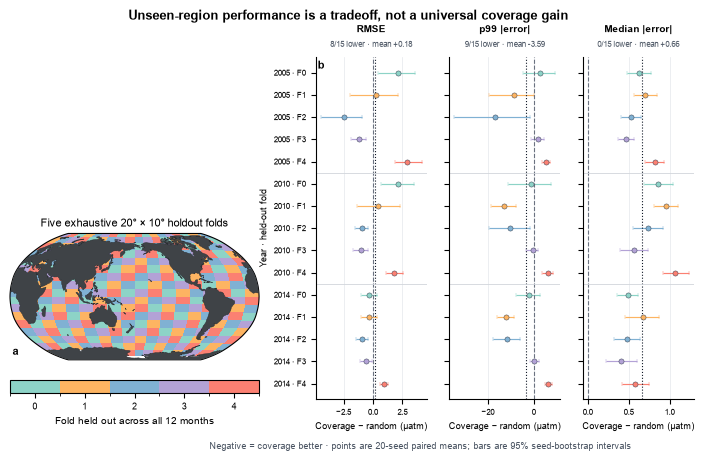

In [9]:
spatial_gate_figure = plot_spatial_holdout_gate(spatial_blocks, spatial_summary)

**What changed under the stricter gate?** At budget 5,000, coverage has lower RMSE in 8/15 year–fold units and higher RMSE in 7/15; the descriptive mean is only **+0.179 µatm**. Its p99 absolute error is lower in 9/15 units, with a mean difference of **−3.590 µatm**, while median absolute error is higher in all 15 units (mean **+0.663 µatm**). Negative differences favour coverage.

This does not invalidate the random hidden-cell result. It defines its boundary: coverage consistently trades higher typical error for fewer severe failures, but its RMSE advantage does not reliably transfer to an entire unseen region. The 15 year–fold units are a descriptive consistency check, not independent replicates for a new significance test.

---
## Result

<div style="padding:18px;background:#111827;color:#F9FAFB;border-radius:8px;font-size:16px;line-height:1.45;">
Better ocean-carbon sampling is not simply about collecting more observations. Under a fixed annual budget with closely matched monthly allocation, spatial geometry redistributes error. Seasonally balanced spatial coverage reduces severe tail failures more often, but consistently raises typical error; its effect on RMSE changes with year and unseen region.
</div>

**Supported:** a repeatable fixed-model interpolation result and a three-year, five-fold, 20-seed spatial generalisation experiment that exposes its boundary.  
**Not yet supported:** universal superiority, buffered extrapolation, cross-model robustness, or direct real-ocean performance.